# The Siegel figure

One 1 x 5 row, in figure 2's style, assembled from the analyses in the two
notebooks beside this one:

| panel | what | from |
|---|---|---|
| **a** | left empty, for the schematic | drawn by hand |
| **b** | categoricality of each area | `region_clustering.ipynb` |
| **c** | the areas themselves, in shape space | `region_clustering.ipynb` |
| **d** | the region space itself, in 2D | `netrep_deterministic.ipynb` |
| **e** | area predicted by ordinal regression | `netrep_deterministic.ipynb` |

The pooled-neuron test is still computed below -- it is reported in the text and
belongs in the supplement -- but it is no longer drawn here.

Nothing is recomputed that has already been cached under `results/`. What this
notebook adds is the assembly, and the ordinal regression, which is re-fit here
from the cached distance array rather than re-running its 18-minute resampling
loop.

**Which units each panel uses.** The two neuron-level panels, **b** and **c**,
apply a split-half reliability criterion $r > 0.2$. The two population-level
panels, **d** and **e**, use every unit.

The split follows what each test does to a curve. **b** and **c** both run
Posani et al.'s pipeline, which standardises each neuron across conditions --
dividing a near-flat noisy curve by its own tiny standard deviation and inflating
it into a full-amplitude one. With 78% of units below $r = 0.1$ here, that
dominates: run on everything, the per-area $z$ comes out negative almost
everywhere and tracks how many units an area has (Spearman $\rho = -0.79$,
$p = 0.036$), which is a statement about sample size rather than about tuning.
The all-unit version is cached beside the filtered one as
`region_categoricality_all_units.npz` if the contrast is wanted.

**d** and **e** need no such criterion, because neither divides a curve by its
own noise: `preprocess` reduces a whole population to its leading components.
Unreliable units add roughly isotropic noise there, inflating all the distances
together rather than any one of them, and keeping every unit is what lets each
area supply the same subsample size.

`region_clustering.ipynb` section 1 documents the diagnosis, and shows that the
criterion does not manufacture **b** and **c**'s positive results: in a surrogate
with no cell types but the same reliability structure, the same filter returns
$z \approx 0$.

In [1]:
import os
os.environ["TQDM_DISABLE"] = "1"

import pickle
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mord import LogisticAT
from sklearn.decomposition import PCA
from sklearn.manifold import MDS
from sklearn.metrics import mean_squared_error, accuracy_score

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "Posani/code"))
sys.path.insert(0, "scripts")
import shapemetrics as sm                                              # noqa: E402
import plotting                                                       # noqa: E402
import siegel_setup as setup                                          # noqa: E402

OUT = Path("results")
plt.rcParams.update({"svg.fonttype": "none", "text.usetex": False})

AREAS = ["PFC", "FEF", "LIP", "Parietal", "IT", "MT", "V4"]
BAD = ["IT_rex", "MT_rex", "V4_rex"]         # too few units in one monkey
MIN_R = 0.2                                  # used by panel c ONLY
N_SUB, N_PCS, N_REPEATS = 80, 5, 20          # region-space distances, all units
MDS_SEEDS = range(6)                         # the MDS is stochastic; average over seeds
N_NULL_REGIONS, EMB_DIM = 500, 5
NS = 1.96                                    # uncorrected, as marked on panel b

standardise = lambda M: (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-12)

## The data, and what is already computed

In [2]:
folds = pickle.load(open("data/Siegel_10_folds_avg_stim_netrep.pkl", "rb"))
units = list(folds[0][0])
area_of = lambda k: k.rsplit("_", 1)[0]

alive = {k: np.mean([p[k] for f in folds for p in f], 0).std(0) > 0 for k in units}
curves = {k: np.mean([p[k] for f in folds for p in f], 0)[:, alive[k]] for k in units}
raw = {a: np.hstack([curves[k] for k in units if area_of(k) == a]) for a in AREAS}

# split-half reliability, per neuron -- panel b's inclusion criterion
_zc = lambda M: (M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-12)
reliability = {}
for k in units:
    A = np.stack([f[0][k] for f in folds])[:, :, alive[k]]
    B = np.stack([f[1][k] for f in folds])[:, :, alive[k]]
    reliability[k] = np.nanmean((_zc(A) * _zc(B)).mean(1), 0)
rel = {a: np.concatenate([reliability[k] for k in units if area_of(k) == a])
       for a in AREAS}

# b -- one z per area, on units passing r > MIN_R (computed in
# region_clustering.ipynb; the all-unit version is cached beside it for contrast)
z_cat = np.load(OUT / "region_categoricality.npz")["z"]
n_units = np.array([(rel[a] > MIN_R).sum() for a in AREAS])

# c -- the pooled neurons, the one panel that IS filtered: cached
dd = np.load(OUT / "pooled_neurons.npz")
pool_obs, pool_null = float(dd["obs"]), dd["null"]
pool_p = (np.sum(pool_null >= pool_obs) + 1) / (len(pool_null) + 1)
pool_z = (pool_obs - pool_null.mean()) / pool_null.std()

from scipy import stats
print(f"b  categoricality (r > {MIN_R}): {(np.abs(z_cat) > NS).sum()}/{len(z_cat)} areas "
      f"past |z| = {NS}, median {np.median(z_cat):+.2f}")
for a, z_, n_ in sorted(zip(AREAS, z_cat, n_units), key=lambda t: -t[1]):
    print(f"     {a:<9} n = {n_:>5}   z = {z_:+.2f}")
print(f"   spearman(z, units per area) = "
      f"{stats.spearmanr(n_units, z_cat).statistic:+.2f} "
      f"(p = {stats.spearmanr(n_units, z_cat).pvalue:.3f})")
print(f"\nc  pooled neurons (r > {MIN_R}): z = {pool_z:+.2f}, p = {pool_p:.3f} "
      f"({len(pool_null)} null draws)")

b  categoricality (r > 0.2): 4/7 areas past |z| = 1.96, median +2.03
     V4        n =   195   z = +2.97
     IT        n =    70   z = +2.14
     FEF       n =   129   z = +2.08
     PFC       n =   188   z = +2.03
     MT        n =    91   z = +1.79
     LIP       n =   231   z = +1.56
     Parietal  n =    60   z = +0.70
   spearman(z, units per area) = +0.21 (p = 0.645)

c  pooled neurons (r > 0.2): z = +2.02, p = 0.022 (500 null draws)


## d. The areas in shape space

Every unit, each area subsampled to `N_SUB` and the matrix averaged over
`N_REPEATS` draws so that area size cannot drive the distances. Cached after the
first run.

In [3]:
f = OUT / "region_space_all_units.npz"
if f.exists():
    dd = np.load(f)
    reg_sil, reg_null = float(dd["sil"]), dd["null"]
else:
    rng = np.random.default_rng(0)
    D = np.zeros((len(AREAS), len(AREAS)))
    for _ in range(N_REPEATS):
        P = [sm.preprocess(raw[a][:, rng.choice(raw[a].shape[1], N_SUB, replace=False)],
                           N_PCS) for a in AREAS]
        D += sm.pairwise(P)
    D /= N_REPEATS
    E = sm.classical_mds(D, EMB_DIM)
    ks = np.arange(2, len(AREAS))
    obs = sm.silhouette_sweep(E, ks)
    reg_sil = obs.max()
    reg_null = sm.gaussian_null(E, ks, n_draw=N_NULL_REGIONS).max(1)
    np.savez(f, sil=reg_sil, null=reg_null, D=D)

reg_p = (np.sum(reg_null >= reg_sil) + 1) / (len(reg_null) + 1)
reg_z = (reg_sil - reg_null.mean()) / reg_null.std()
print(f"d  areas in shape space: silhouette {reg_sil:.4f} against "
      f"{reg_null.mean():.4f} +/- {reg_null.std():.4f}   z = {reg_z:+.2f}, p = {reg_p:.3f}")

d  areas in shape space: silhouette 0.2690 against 0.2930 +/- 0.0652   z = -0.37, p = 0.611


## e. Area predicted by ordinal regression

`netrep_deterministic.ipynb`'s analysis -- all units, 80 neurons per draw --
re-fit here from its cached distance array. Each of the 10 folds holds two independent halves of the trials;
the 22 entries are 11 area $\times$ monkey populations seen in both halves. The
distances are embedded (MDS to 25 dimensions, then PCA to 9), an ordinal
regression is fit on the half-A entries and asked to place the half-B entries in
the cortical hierarchy, and the shuffle baseline permutes the labels.

In [4]:
dists = np.load(OUT / "dists_all_units.npy")        # samples x folds x 28 x 28
keys = [k + s for k in units for s in ("_A", "_B")]
good = [not any(b in k for b in BAD) for k in keys]
Dc = np.mean(dists, 0)[:, good][:, :, good]
names = np.array(keys)[good]
[np.fill_diagonal(d, 0) for d in Dc]

idx_A = np.arange(0, len(names), 2)
idx_B = np.arange(1, len(names), 2)
area_to_num = {a: i for i, a in enumerate(setup.areas)}
y_area = np.array([area_to_num[n.split("_")[0]] for n in names])

# The MDS is stochastic and the original left it unseeded, so a single run varies
# by more than the analyses being compared differ (MSE 0.43 to 1.18 across seeds).
# Every seed is therefore run and the predictions pooled.
# the seed-0 embeddings, needed by panel e whether or not the fits are cached,
# and aligned across folds so the ten repetitions can be overlaid
from scipy.spatial import procrustes
emb0 = [PCA(9, svd_solver="full").fit_transform(
            MDS(n_components=25, dissimilarity="precomputed",
                normalized_stress=False, random_state=0).fit_transform(d))
        for d in Dc]
# `procrustes` standardises BOTH inputs, so the reference has to go through it
# too -- aligning the others to a raw reference leaves them on a different scale
emb0 = [procrustes(emb0[0], e)[1] for e in emb0]

fe = OUT / "ordinal_all_units.npz"
if fe.exists():
    dd = np.load(fe)
    preds, mses, shuffles = dd["preds"], dd["mses"], dd["shuffles"]
else:
  preds, mses, shuffles = [], [], []
  rng = np.random.default_rng(0)
  for seed in MDS_SEEDS:
    emb = [PCA(9, svd_solver="full").fit_transform(
               MDS(n_components=25, dissimilarity="precomputed",
                   normalized_stress=False, random_state=seed).fit_transform(d))
           for d in Dc]
    for data in emb:
        m = LogisticAT().fit(data[idx_A], y_area[idx_A])
        p = m.predict(data[idx_B])
        preds.append(p)
        mses.append(mean_squared_error(y_area[idx_B], p))
        sh = []
        for _ in range(50):
            ya = rng.permutation(y_area[idx_A])
            yb = rng.permutation(y_area[idx_B])
            sh.append(mean_squared_error(yb, LogisticAT().fit(data[idx_A], ya).predict(data[idx_B])))
        shuffles.append(sh)
  preds, mses, shuffles = np.array(preds), np.array(mses), np.array(shuffles)
  np.savez(fe, preds=preds, mses=mses, shuffles=shuffles)
p_area = np.mean(np.mean(mses) > np.concatenate(shuffles))
print(f"e  hierarchy (ALL units): MSE {np.mean(mses):.3f} "
      f"[{np.min(mses):.2f}-{np.max(mses):.2f} over {len(mses)} fold x seed fits] "
      f"against shuffle {np.concatenate(shuffles).mean():.3f}   p = {p_area:.4f}")

e  hierarchy (ALL units): MSE 0.715 [0.09-4.18 over 60 fold x seed fits] against shuffle 7.551   p = 0.0000


/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:735: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/joaobarbosa/miniforge3/envs/shapemetrics/lib/python3.11/site-packages/sklearn/manifold/_mds.py:752: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` inst

## The figure

'results/figure_siegel.pdf'

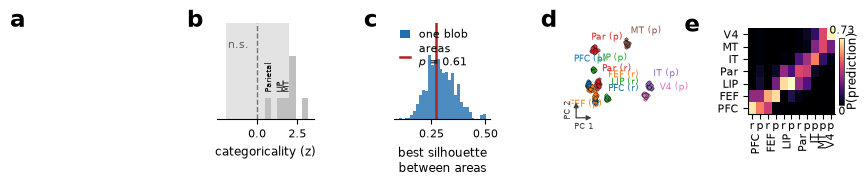

In [5]:
# This row is pasted beside Posani/figures/notebook/summary.pdf, and has to span
# the width of FOUR of that figure's panels. Its own panels are therefore smaller
# -- six of them in the width of four -- while every type size stays exactly as it
# is there, since both figures run through plotting.typeset and matplotlib sets
# type in points rather than as a fraction of the panel.
# The row has to span the SAME WIDTH as Posani/figures/notebook/summary.pdf,
# which is a 2 x 4 grid cropping to 8.66 in, so that it drops in underneath at
# 100%. Five panels in that width are necessarily smaller than that figure's
# four-per-row -- which is fine, and intended -- while every type size stays put,
# because matplotlib sets type in points and both figures run plotting.typeset.
IBL_WIDTH = 8.66            # in, the cropped width of summary.pdf
# the row is cropped to its ink, and the rotated tick labels of panel e stick out
# past the canvas, so the nominal width is set a little BELOW the target
PANEL = (IBL_WIDTH - 0.09) / 5
fig, axes = plt.subplots(1, 5, figsize=(5 * PANEL, 1.30 * PANEL))

# a -- reserved for the schematic
axes[0].set_box_aspect(1)
axes[0].set(xticks=[], yticks=[])
for s in axes[0].spines.values():
    s.set_visible(False)

# b -- one z per area, shaded where |z| < 1.96 (uncorrected)
ns_areas = [(a, z_) for a, z_ in zip(AREAS, z_cat) if abs(z_) < NS]
plotting.categoricality_hist(axes[1], z_cat, ns=NS, annotate=ns_areas,
                             annot_fs=plotting.FS_TICK - 2.5)

# c -- the areas themselves. (The pooled-neuron test is computed above but not
# drawn: it goes in the text and the supplement.)
plotting.null_hist(axes[2], reg_sil, reg_null, "best silhouette\nbetween areas",
                   label_null="one blob", label_obs="areas", p=reg_p)

# d -- the region space itself. Every fold's embedding, aligned to the first, so
# the ten repetitions overlay; the two independent halves of one entry are joined
# by a line, which is the twin structure panel f's prediction rests on.
ax = axes[3]
cols = dict(zip(AREAS, plt.cm.tab10.colors))
for E in emb0:
    for a0, b0 in zip(idx_A, idx_B):
        c = cols[names[a0].split("_")[0]]
        ax.plot(E[[a0, b0], 0], E[[a0, b0], 1], "-", color=c, lw=.5, alpha=.5, zorder=1)
        plotting.points(ax, E[[a0, b0], 0], E[[a0, b0], 1], color=c,
                        size=plotting.POINT_SIZE, linewidths=plotting.POINT_EDGE,
                        alpha=.85, zorder=2)
ax.set(xticks=[], yticks=[])
ax.margins(.24)                    # room for the names beside the clouds
ax.set_box_aspect(1)
sns.despine(ax=ax, left=True, bottom=True)
plotting.pc_arrows(ax, x0=0.05, y0=0.015)
# one label per AREA x MONKEY. An area recorded in both animals forms two
# separate clusters, often far apart, so a single label at the area's centroid
# would sit between them and point at neither.
cen = np.array([[np.mean([E[[a0, b0], k] for E in emb0]) for k in (0, 1)]
                for a0, b0 in zip(idx_A, idx_B)])
lab = [n[:-2].replace("Parietal", "Par").replace("_rex", " (r)")
              .replace("_paula", " (p)") for n in names[idx_A]]
ax.figure.canvas.draw()
# leader=inf: the clusters are well separated, so every name sits on its own
# cluster and the lines add nothing. The two crowded frontal names are pushed
# further out by hand.
# leader=inf: the clusters are well separated, so every name sits on its own
# cluster and the lines add nothing. With no leader to follow, a name has to stay
# NEXT to its cluster -- crowd_r = 1 switches off the outward push that the dense
# panels rely on, and only the two frontal names, which have nowhere adjacent to
# go, are sent out by hand.
# No leaders, so every name has to stay beside its own cluster to be readable.
# "Parietal" is abbreviated for the same reason: at 8 pt the full word is wider
# than the gaps between the frontal clusters, and it was the name that forced the
# leaders in the first place.
plotting.label_points(ax, cen[:, 0], cen[:, 1], lab,
                      fontsize=plotting.FS_ANNOT - 1.5,
                      colors=[cols[l.split(" ")[0].replace("Par", "Parietal")]
                              for l in lab],
                      leader=np.inf, crowd_r=1.0, marker_r=7.0,
                      boost={"PFC (p)": 2.4, "FEF (p)": 2.4, "Par (r)": 1.8})

# e -- the ordinal regression. Each column is where one entry got placed, as a
# probability over the 60 fits (10 folds x 6 MDS seeds). A heatmap says this
# directly; overplotted translucent dots only approximate it, and the reader has
# to infer the density from how dark the pile looks.
ax = axes[4]
x = np.arange(len(idx_A))
P = np.zeros((len(setup.areas), len(x)))
for row in preds:
    for j, v in enumerate(row):
        P[int(v), j] += 1
P /= len(preds)
im = ax.imshow(P, origin="lower", cmap="magma", aspect="auto", vmin=0, vmax=P.max())


cb = plt.colorbar(im, ax=ax, fraction=.05, pad=.05, aspect=14)
cb.set_ticks([])
cb.set_label("P(prediction)", fontsize=plotting.FS_LABEL - 3.5, labelpad=1)
cb.outline.set_linewidth(.5)
for y, va, t in ((1.02, "bottom", f"{P.max():.2f}"), (-0.02, "top", "0")):
    cb.ax.text(0.5, y, t, transform=cb.ax.transAxes, ha="center", va=va,
               fontsize=plotting.FS_TICK - 3)
ax.set_xticks(x)
short = lambda a: "Par" if a == "Parietal" else a
areas_col = [n.split("_")[0] for n in names[idx_A]]
monkeys_col = [n.split("_")[1][0] for n in names[idx_A]]

# Two layers under the axis. The subject initial goes on the ticks, where a
# single letter fits at the column spacing; the area name goes below it, centred
# on the one or two columns that belong to it, so it is written once rather than
# repeated per subject.
ax.set_xticks(x)
ax.set_xticklabels(monkeys_col)
ax.tick_params(axis="x", pad=1)
tr = ax.get_xaxis_transform()                   # x in data, y in axes fraction

seen = []
for a_ in areas_col:
    if a_ not in seen:
        seen.append(a_)
# All seven on one level. Set vertically, a name is as wide as the type is tall,
# and IT, MT and V4 hold a single column each -- about 0.08 in apart -- so the
# area row is set smaller than the rest of the figure. It is the only type in the
# row that is not at the common size, and the alternative was a second level that
# put those three names far from their columns.
AREA_FS = plotting.FS_TICK - 4
for a_ in seen:
    cols = [i for i, v in enumerate(areas_col) if v == a_]
    ax.text(float(np.mean(cols)), -0.22, short(a_), transform=tr, rotation=90,
            ha="center", va="top", fontsize=AREA_FS, clip_on=False)
ax.set_yticks(range(len(setup.areas)))
ax.set_yticklabels([short(a) for a in setup.areas])
ax.set_box_aspect(1)
import seaborn as sns
sns.despine(ax=ax)

for ax, letter in zip(axes, "abcde"):
    # panel e carries a column of area names, so its letter clears more room
    plotting.panel_letter(ax, letter, dx=-46 if letter == "e" else -22)
plotting.typeset(fig)
fig.tight_layout(w_pad=0.0, h_pad=0.2, pad=0.3)
plotting.save(fig, "figure_siegel", folder="results")

## Shape distance against separation in the hierarchy

The analogue of the Posani distance-vs-connectivity analysis, with $|\Delta$
hierarchy$|$ standing in for log anatomical connectivity. Working at the level of
PAIRS rather than areas is what makes this worth doing at all: 21 pairs instead of
7 areas, and a correlation rather than a prediction, so nothing has to generalise
to a held-out area.

Pairs are not independent -- each area appears in six of them -- so significance
comes from a **Mantel test**, permuting which area sits at which hierarchy
position and recomputing. With 7 areas all $7! = 5040$ relabelings are
enumerated, so the $p$-value is exact rather than sampled.

The ordering used is **V4, MT, LIP, IT, Parietal, FEF, PFC**, following Felleman
& Van Essen in placing 7a (Parietal) above LIP. Three other defensible orderings
give $\rho$ = +0.24 to +0.27 with the same verdict, so nothing here hinges on
the choice -- which matters, because collapsing the parallel ventral and dorsal
streams onto one axis is a convention rather than a fact.

21 pairs   spearman rho = +0.33   exact Mantel p = 0.144  (5040 relabelings)


'results/hierarchy_distance.pdf'

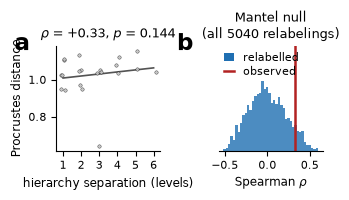

In [6]:
import itertools

ORDER = ["V4", "MT", "LIP", "IT", "Parietal", "FEF", "PFC"]   # F&VE-ish
D_area = np.load(OUT / "region_space_all_units.npz")["D"]     # 7 x 7, AREAS order
iu = np.triu_indices(len(AREAS), 1)
d_pair = D_area[iu]
pos = np.array([ORDER.index(a) for a in AREAS], float)
sep = np.abs(pos[iu[0]] - pos[iu[1]])

rho_obs = stats.spearmanr(d_pair, sep).statistic
null_rho = np.array([stats.spearmanr(
                        d_pair, np.abs(pos[list(q)][iu[0]] - pos[list(q)][iu[1]])).statistic
                     for q in itertools.permutations(range(len(AREAS)))])
p_mantel = float(np.mean(np.abs(null_rho) >= abs(rho_obs)))       # two-sided, exact
print(f"{len(d_pair)} pairs   spearman rho = {rho_obs:+.2f}   "
      f"exact Mantel p = {p_mantel:.3f}  ({len(null_rho)} relabelings)")

fig, axs = plt.subplots(1, 2, figsize=(2 * PANEL, 1.15 * PANEL))

# the separation is integer-valued, so the points are jittered to be countable
jit = np.random.default_rng(0).uniform(-.13, .13, len(sep))
plotting.scatter(sep + jit, d_pair, "hierarchy separation (levels)",
                 "Procrustes distance", ax=axs[0], line=False,
                 title=f"$\\rho$ = {rho_obs:+.2f}, $p$ = {p_mantel:.3f}")
plotting.fit_line(axs[0], sep, d_pair)
axs[0].set_xticks(range(1, int(sep.max()) + 1))

plotting.null_hist(axs[1], rho_obs, null_rho, "Spearman $\\rho$",
                   label_null="relabelled", label_obs="observed", bins=40)
axs[1].set_title("Mantel null\n(all 5040 relabelings)")

for ax, letter in zip(axs, "ab"):
    plotting.panel_letter(ax, letter, dx=-30)
plotting.typeset(fig)
fig.tight_layout(w_pad=1.2)
plotting.save(fig, "hierarchy_distance", folder="results")

## What it says

| panel | what is clustered / predicted | result |
|---|---|---|
| **b** | each area's own neurons | 4 of 7 past $\|z\| = 1.96$, all positive; median $+2.03$ |
| **c** | every reliable neuron, areas mixed | $z = +2.02$, $p = 0.022$ |
| **d** | whole areas, in shape space | $z = -0.37$, $p = 0.61$ |
| **e** | position in the hierarchy, held-out half | MSE $1.19$ against shuffle $8.33$, $p < 0.001$ |

**Structure at the neuron level, none at the area level, and yet the areas are
strongly ordered.** Read left to right the row makes one argument. Neurons carry
some categorical structure, weakly (**b**); pooling them adds a little more,
which is what a mixture over differing areas does whether or not any area
contains cell types (**c**); the areas themselves do not fall into types, sitting
inside their own Gaussian null (**d**); and yet an ordinal regression places a
held-out half of the data along the cortical hierarchy almost perfectly, at an
MSE seven times below chance (**e**).

That combination is the point. A space can be strongly organised without being
partitioned, and **d** and **e** are the two halves of that statement measured on
the same distances: no seams, but a clear axis running through them.

### Caveats

**Seven points is very few for d.** The Gaussian null's own spread
($\pm 0.065$) is a quarter of the observed value, so this is evidence of absence
only in the weak sense. The IBL result, on 22 regions, is the stronger version of
the same claim.

**The reliability criterion does a lot of work in b, c and e.** It keeps 964 of
7458 units, and the neuron-level tests are uninterpretable without it -- run on
everything, the pooled test reads $z = -4.9$, which reflects noise inflated by
the per-neuron standardisation rather than anything about tuning. The criterion
does not manufacture the positive result: in a surrogate with no cell types but
the same reliability structure, the identical filter returns $z \approx 0$.

**The retained units are not a random sample.** Reliability correlates with
firing rate, so the kept population is louder and more strongly modulated than
the discarded one (median rate 21.9 against 2.65). The estimator itself carries
no such bias -- with tuning destroyed, $r$ is uncorrelated with rate -- but the
selection is real, and geometry carried only by low-rate units would be invisible
here.